# Load Data Set

In [1]:
import tensorflow as tf

from tensorflow.keras.datasets import mnist

# Load Dataset
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 16s 1us/step


# verify Data Set Loaded

In [2]:
print("X_train Shape:", X_train.shape)

print("Y_train Shape:", Y_train.shape)

print("X_test Shape:", X_test.shape)

print("Y_test Shape:", Y_test.shape)

X_train Shape: (60000, 28, 28)
Y_train Shape: (60000,)
X_test Shape: (10000, 28, 28)
Y_test Shape: (10000,)


# Visulaize Image

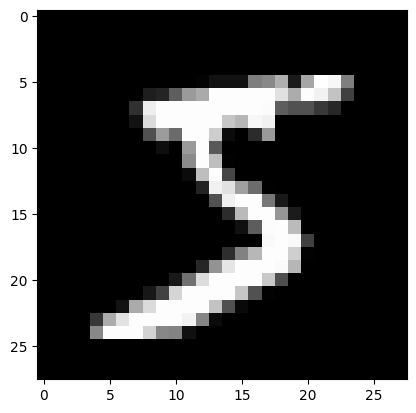

Label: 5


In [3]:
import matplotlib.pyplot as plt

plt.imshow(X_train[0], cmap='gray')

plt.show()

print("Label:", Y_train[0])

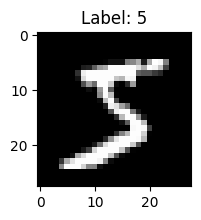

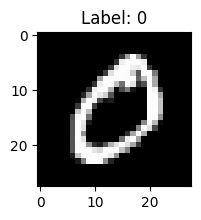

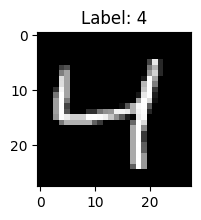

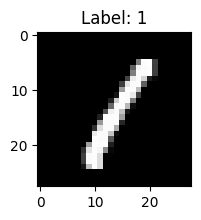

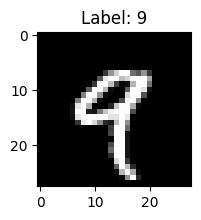

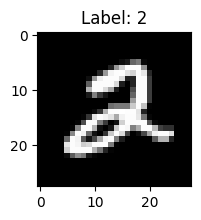

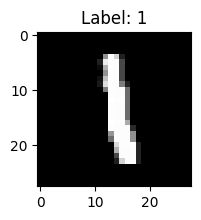

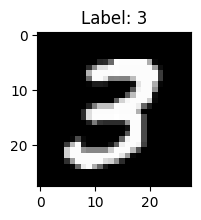

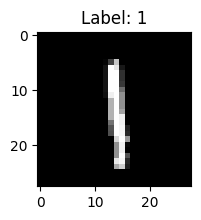

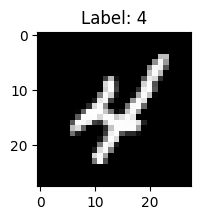

In [4]:
import matplotlib.pyplot as plt

for i in range(10):
    
    plt.figure(figsize=(2,2))
    
    plt.imshow(
        X_train[i],
        cmap='gray'
    )
    
    plt.title(
        f"Label: {Y_train[i]}"
    )
    
    plt.show()

# Normalize Image Pixels

In [5]:
# Normalize Training Data

X_train = X_train / 255.0

# Normalize Testing Data

X_test = X_test / 255.0

## Verify 

In [6]:
print(X_train.min())
print(X_train.max())

0.0
1.0


# Understand Classes

In [7]:
import numpy as np

print("Classes:")

print(np.unique(Y_train))

Classes:
[0 1 2 3 4 5 6 7 8 9]


# Count Images Per Class

In [8]:
import pandas as pd

pd.Series(Y_train).value_counts().sort_index()

0    5923
1    6742
2    5958
3    6131
4    5842
5    5421
6    5918
7    6265
8    5851
9    5949
Name: count, dtype: int64

# Flatten Dataset

In [9]:
X_train = X_train.reshape(60000, 784)

X_test = X_test.reshape(10000, 784)

In [10]:
print(X_train.shape)

print(X_test.shape)

(60000, 784)
(10000, 784)


# Model

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Create ANN Model
model = Sequential()

# Hidden Layer 1
model.add(
    Dense(
        128,
        activation='relu',
        input_shape=(784,)
    )
)

# Hidden Layer 2
model.add(
    Dense(
        64,
        activation='relu'
    )
)

# Output Layer
model.add(
    Dense(
        10,
        activation='softmax'
    )
)

C:\Users\Digital\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

# Compile 

In [14]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#  Train

In [15]:
history = model.fit(
    X_train,
    Y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9204 - loss: 0.2675 - val_accuracy: 0.9567 - val_loss: 0.1484
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9656 - loss: 0.1119 - val_accuracy: 0.9694 - val_loss: 0.1037
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9764 - loss: 0.0756 - val_accuracy: 0.9628 - val_loss: 0.1205
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9815 - loss: 0.0584 - val_accuracy: 0.9710 - val_loss: 0.0966
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9862 - loss: 0.0436 - val_accuracy: 0.9711 - val_loss: 0.0993
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9883 - loss: 0.0356 - val_accuracy: 0.9748 - val_loss: 0.0909
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9912 - loss: 0.0266 - val_accuracy: 0.9751 - val_loss: 0.0956
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9914 - loss: 

# Evaluate

In [16]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    Y_test
)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9770 - loss: 0.0943
Test Loss : 0.09434494376182556
Test Accuracy : 0.9769999980926514


# Testing

In [17]:
Y_test[0]

np.uint8(7)

In [19]:
prediction = model.predict(
    X_test[0].reshape(1, 784)
)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
[[2.0340185e-10 4.6467532e-09 1.7698217e-07 7.1288048e-07 3.0209250e-14
  1.2774945e-10 1.1386851e-14 9.9999845e-01 1.4987204e-08 5.7458703e-07]]


In [20]:
import numpy as np

predicted_digit = np.argmax(prediction)

print(predicted_digit)

7


In [21]:
import numpy as np

predicted_digit = np.argmax(prediction)

print("Predicted Digit:", predicted_digit)

print("Actual Digit:", Y_test[0])

Predicted Digit: 7
Actual Digit: 7


# Visual Prediction

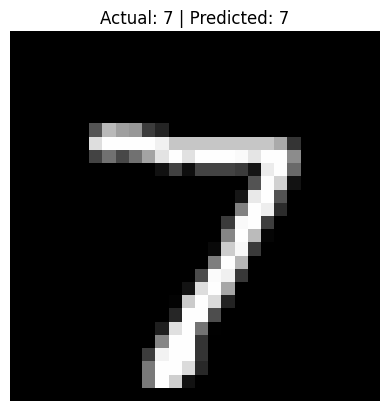

In [22]:
import matplotlib.pyplot as plt

plt.imshow(
    X_test[0].reshape(28,28),
    cmap='gray'
)

plt.title(
    f"Actual: {Y_test[0]} | Predicted: {predicted_digit}"
)

plt.axis('off')

plt.show()

# Test Multiple Images

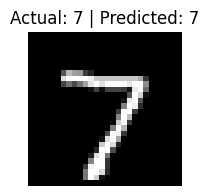

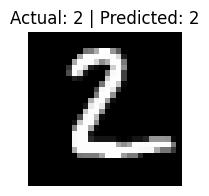

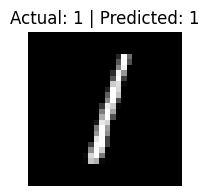

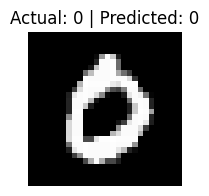

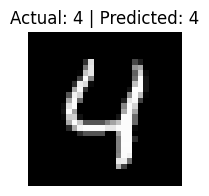

In [23]:
for i in range(5):

    prediction = model.predict(
        X_test[i].reshape(1,784),
        verbose=0
    )

    predicted_digit = np.argmax(prediction)

    plt.figure(figsize=(2,2))

    plt.imshow(
        X_test[i].reshape(28,28),
        cmap='gray'
    )

    plt.title(
        f"Actual: {Y_test[i]} | Predicted: {predicted_digit}"
    )

    plt.axis('off')

    plt.show()